# Additional Model Metrics

Extends the model comparison with additional metrics:

1. **Mean choice probability** — average probability the model assigns to the actually-chosen combo (i.e., mean likelihood without the log). More interpretable than log-likelihood.
2. **Total Variation Distance (TVD)** — half the L1 distance between predicted and observed combo distributions. Ranges 0 (identical) to 1 (disjoint).
3. **Intersection over Union (IoU)** — overlap between predicted and observed distributions, measured as sum of min(p,q) / sum of max(p,q).
4. **Scatter plots** — predicted vs observed combo frequencies for each model.

In [1]:

import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

from shared import EXPORTS_DIR, DATA_ROOT
from shared.constants import (
    F, T, M, ROLE_NAMES, ROLE_SHORT, ROLE_CHAR_TO_IDX,
    ALL_ROLE_COMBOS, TURNS_PER_STAGE, ROLE_COMBO_TO_ENV_NUM,
)
from shared.parsing import canonical_combo
from shared.inference import (
    utility_based_prior, bayesian_update, preferred_action, game_step,
    softmax_role_dist,
)
from shared.evaluation import run_predictions, compute_pearson, extract_metrics
from shared.data_loading import load_all_exports, to_dataframe
from shared.env_loading import make_env_loader

print("Imports OK")


Imports OK


In [2]:

# Load data (same as summary notebook)
player_records = load_all_exports(data_dirs=[
    EXPORTS_DIR / 'bayesian-role-specialization-2026-03-06-09-54-19',
    EXPORTS_DIR / 'bayesian-role-specialization-2026-03-18-15-47-09',
], include_bot_rounds=False, include_dropout_games=False)
df = to_dataframe(player_records)

env_loader = make_env_loader()
team_records = []
grouped = df.groupby(['game_id', 'round_number'])
for (game_id, round_num), group in grouped:
    if len(group) != 3: continue
    group = group.sort_values('player_id')
    players = group.to_dict('records')
    participant_ids = [p['participant_id'] for p in players]
    n_stages = min(p['n_stages'] for p in players)
    stage_roles = [''.join(ROLE_SHORT[players[pos]['role_idxs'][s]] for pos in range(3)) for s in range(n_stages)]
    if not stage_roles: continue
    config = players[0]['config']
    optimal_roles_idx = config.get('optimalRoles', [])
    role_combo = ''.join(ROLE_SHORT[ri] for ri in optimal_roles_idx)
    team_records.append({
        'game_id': game_id, 'round_number': round_num,
        'env_id': f"{players[0]['stat_profile_id']}_{role_combo}",
        'lds': [int(c) for c in players[0]['enemy_intent_sequence']],
        'stage_roles': stage_roles, 'optimal_roles': role_combo,
        'env_config': env_loader(role_combo=role_combo),
        'participant_ids': participant_ids,
    })

all_pids = set(pid for rec in team_records for pid in rec['participant_ids'])
print(f"{len(team_records)} team-rounds, {len(all_pids)} participants")


Loaded bayesian-role-specialization-2026-03-06-09-54-19: 54 player-rounds
Loaded bayesian-role-specialization-2026-03-18-15-47-09: 144 player-rounds
Total: 198 player-rounds from 2 exports
66 team-rounds, 33 participants


In [3]:

# ========== ALL MODEL DEFINITIONS (copied from summary notebook) ==========

# --- Bayesian Walk ---
def make_bayesian_walk(tau_prior, tau_softmax, epsilon, epsilon_switch):
    def predict_fn(record):
        env = record['env_config']
        values, player_stats = env['values'], env['player_stats']
        boss_damage, team_max_hp, enemy_max_hp = env['boss_damage'], env['team_max_hp'], env['enemy_max_hp']
        team_hp, enemy_hp = float(team_max_hp), float(enemy_max_hp)
        prior = utility_based_prior(player_stats, tau=tau_prior)
        results, turn_idx, prev_roles = [], 0, None
        for human_combo in record['stage_roles']:
            if turn_idx >= len(record['lds']) or team_hp <= 0 or enemy_hp <= 0: break
            intent = record['lds'][turn_idx]
            thp, ehp = int(min(max(0, team_hp), team_max_hp)), int(min(max(0, enemy_hp), enemy_max_hp))
            switch_dist = [softmax_role_dist(i, intent, thp, ehp, prior, values, tau_softmax) for i in range(3)]
            per_agent = []
            for i in range(3):
                if prev_roles is None: per_agent.append(switch_dist[i])
                else:
                    stick = np.zeros(3); stick[prev_roles[i]] = 1.0
                    per_agent.append((1.0 - epsilon_switch) * stick + epsilon_switch * switch_dist[i])
            predicted_dist = {}
            for r0 in range(3):
                for r1 in range(3):
                    for r2 in range(3):
                        combo = ROLE_SHORT[r0] + ROLE_SHORT[r1] + ROLE_SHORT[r2]
                        predicted_dist[combo] = float(per_agent[0][r0] * per_agent[1][r1] * per_agent[2][r2])
            results.append({'predicted_dist': predicted_dist, 'human_combo': human_combo,
                           'model_marginal': np.mean(per_agent, axis=0)})
            human_roles = [ROLE_CHAR_TO_IDX[c] for c in human_combo]; prev_roles = human_roles
            for _ in range(TURNS_PER_STAGE):
                if turn_idx >= len(record['lds']) or team_hp <= 0 or enemy_hp <= 0: break
                intent = record['lds'][turn_idx]
                actions = [preferred_action(human_roles[i], intent, team_hp, team_max_hp) for i in range(3)]
                prior = bayesian_update(prior, actions, intent, team_hp, team_max_hp, epsilon)
                team_hp, enemy_hp = game_step(intent, team_hp, enemy_hp, actions, player_stats, boss_damage, team_max_hp)
                turn_idx += 1
        return results
    return predict_fn

# --- Bayesian Threshold ---
def expected_values_per_role(agent_i, intent, team_hp, enemy_hp, prior, values):
    other_agents = [a for a in range(3) if a != agent_i]
    other_probs = np.sum(prior, axis=agent_i)
    total = other_probs.sum()
    other_probs = other_probs / total if total > 0 else np.ones((3, 3)) / 9.0
    ev = np.zeros(3)
    for r_i in range(3):
        for r_j in range(3):
            for r_k in range(3):
                roles = [0,0,0]; roles[agent_i] = r_i; roles[other_agents[0]] = r_j; roles[other_agents[1]] = r_k
                ev[r_i] += other_probs[r_j, r_k] * float(values[roles[0]*9+roles[1]*3+roles[2], intent, team_hp, enemy_hp])
    return ev

def threshold_role_dist(agent_i, intent, team_hp, enemy_hp, prior, values, current_role, delta, tau):
    ev = expected_values_per_role(agent_i, intent, team_hp, enemy_hp, prior, values)
    candidates = [r for r in range(3) if r != current_role and (ev[r] - ev[current_role]) > delta]
    if not candidates:
        dist = np.zeros(3); dist[current_role] = 1.0; return dist
    candidate_vals = np.array([ev[r] for r in candidates])
    scaled = candidate_vals / tau; scaled -= scaled.max()
    exp_vals = np.exp(scaled); probs = exp_vals / exp_vals.sum()
    dist = np.zeros(3)
    for i, r in enumerate(candidates): dist[r] = probs[i]
    return dist

def make_bayesian_thresh(tau_prior, tau_softmax, epsilon, delta):
    def predict_fn(record):
        env = record['env_config']
        values, player_stats = env['values'], env['player_stats']
        boss_damage, team_max_hp, enemy_max_hp = env['boss_damage'], env['team_max_hp'], env['enemy_max_hp']
        team_hp, enemy_hp = float(team_max_hp), float(enemy_max_hp)
        prior = utility_based_prior(player_stats, tau=tau_prior)
        results, turn_idx, prev_roles = [], 0, None
        for human_combo in record['stage_roles']:
            if turn_idx >= len(record['lds']) or team_hp <= 0 or enemy_hp <= 0: break
            intent = record['lds'][turn_idx]
            thp, ehp = int(min(max(0, team_hp), team_max_hp)), int(min(max(0, enemy_hp), enemy_max_hp))
            per_agent = []
            for i in range(3):
                if prev_roles is None:
                    per_agent.append(softmax_role_dist(i, intent, thp, ehp, prior, values, tau_softmax))
                else:
                    per_agent.append(threshold_role_dist(i, intent, thp, ehp, prior, values,
                        current_role=prev_roles[i], delta=delta, tau=tau_softmax))
            predicted_dist = {}
            for r0 in range(3):
                for r1 in range(3):
                    for r2 in range(3):
                        combo = ROLE_SHORT[r0] + ROLE_SHORT[r1] + ROLE_SHORT[r2]
                        predicted_dist[combo] = float(per_agent[0][r0] * per_agent[1][r1] * per_agent[2][r2])
            results.append({'predicted_dist': predicted_dist, 'human_combo': human_combo,
                           'model_marginal': np.mean(per_agent, axis=0)})
            human_roles = [ROLE_CHAR_TO_IDX[c] for c in human_combo]; prev_roles = human_roles
            for _ in range(TURNS_PER_STAGE):
                if turn_idx >= len(record['lds']) or team_hp <= 0 or enemy_hp <= 0: break
                intent = record['lds'][turn_idx]
                actions = [preferred_action(human_roles[i], intent, team_hp, team_max_hp) for i in range(3)]
                prior = bayesian_update(prior, actions, intent, team_hp, team_max_hp, epsilon)
                team_hp, enemy_hp = game_step(intent, team_hp, enemy_hp, actions, player_stats, boss_damage, team_max_hp)
                turn_idx += 1
        return results
    return predict_fn

# --- Bayesian-Value ---
def make_bayesian_value(tau_prior, tau_softmax, epsilon):
    def predict_fn(record):
        env = record['env_config']
        values, player_stats = env['values'], env['player_stats']
        boss_damage, team_max_hp, enemy_max_hp = env['boss_damage'], env['team_max_hp'], env['enemy_max_hp']
        team_hp, enemy_hp = float(team_max_hp), float(enemy_max_hp)
        prior = utility_based_prior(player_stats, tau=tau_prior)
        results, turn_idx = [], 0
        for human_combo in record['stage_roles']:
            if turn_idx >= len(record['lds']) or team_hp <= 0 or enemy_hp <= 0: break
            intent = record['lds'][turn_idx]
            thp, ehp = int(min(max(0, team_hp), team_max_hp)), int(min(max(0, enemy_hp), enemy_max_hp))
            per_agent = [softmax_role_dist(i, intent, thp, ehp, prior, values, tau_softmax) for i in range(3)]
            predicted_dist = {}
            for r0 in range(3):
                for r1 in range(3):
                    for r2 in range(3):
                        combo = ROLE_SHORT[r0] + ROLE_SHORT[r1] + ROLE_SHORT[r2]
                        predicted_dist[combo] = float(per_agent[0][r0] * per_agent[1][r1] * per_agent[2][r2])
            results.append({'predicted_dist': predicted_dist, 'human_combo': human_combo,
                           'model_marginal': np.mean(per_agent, axis=0)})
            human_roles = [ROLE_CHAR_TO_IDX[c] for c in human_combo]
            for _ in range(TURNS_PER_STAGE):
                if turn_idx >= len(record['lds']) or team_hp <= 0 or enemy_hp <= 0: break
                intent = record['lds'][turn_idx]
                actions = [preferred_action(human_roles[i], intent, team_hp, team_max_hp) for i in range(3)]
                prior = bayesian_update(prior, actions, intent, team_hp, team_max_hp, epsilon)
                team_hp, enemy_hp = game_step(intent, team_hp, enemy_hp, actions, player_stats, boss_damage, team_max_hp)
                turn_idx += 1
        return results
    return predict_fn

# --- Bayesian-Belief ---
def make_bayesian_belief(tau_prior, epsilon):
    def predict_fn(record):
        env = record['env_config']
        player_stats = env['player_stats']
        boss_damage, team_max_hp, enemy_max_hp = env['boss_damage'], env['team_max_hp'], env['enemy_max_hp']
        team_hp, enemy_hp = float(team_max_hp), float(enemy_max_hp)
        prior = utility_based_prior(player_stats, tau=tau_prior)
        results, turn_idx = [], 0
        for human_combo in record['stage_roles']:
            if turn_idx >= len(record['lds']) or team_hp <= 0 or enemy_hp <= 0: break
            per_agent = []
            for i in range(3):
                marg = np.sum(prior, axis=tuple(j for j in range(3) if j != i))
                total = marg.sum()
                per_agent.append(marg / total if total > 0 else np.ones(3) / 3)
            predicted_dist = {}
            for r0 in range(3):
                for r1 in range(3):
                    for r2 in range(3):
                        combo = ROLE_SHORT[r0] + ROLE_SHORT[r1] + ROLE_SHORT[r2]
                        predicted_dist[combo] = float(per_agent[0][r0] * per_agent[1][r1] * per_agent[2][r2])
            results.append({'predicted_dist': predicted_dist, 'human_combo': human_combo,
                           'model_marginal': np.mean(per_agent, axis=0)})
            human_roles = [ROLE_CHAR_TO_IDX[c] for c in human_combo]
            for _ in range(TURNS_PER_STAGE):
                if turn_idx >= len(record['lds']) or team_hp <= 0 or enemy_hp <= 0: break
                intent = record['lds'][turn_idx]
                actions = [preferred_action(human_roles[i], intent, team_hp, team_max_hp) for i in range(3)]
                prior = bayesian_update(prior, actions, intent, team_hp, team_max_hp, epsilon)
                team_hp, enemy_hp = game_step(intent, team_hp, enemy_hp, actions, player_stats, boss_damage, team_max_hp)
                turn_idx += 1
        return results
    return predict_fn

# --- Random Walk ---
def make_random_walk(eps):
    def predict_fn(record):
        preds = []
        for s, human_combo in enumerate(record['stage_roles']):
            prev = record['stage_roles'][s - 1] if s > 0 else None
            if prev is None: dist = {c: 1.0 / 27 for c in ALL_ROLE_COMBOS}
            else:
                dist = {}
                for combo in ALL_ROLE_COMBOS:
                    p = 1.0
                    for i, (c, prev_c) in enumerate(zip(combo, prev)):
                        p *= (1.0 - eps) if c == prev_c else (eps / 2.0)
                    dist[combo] = p
                total = sum(dist.values()); dist = {c: p/total for c, p in dist.items()}
            marg = np.zeros(3)
            for combo, prob in dist.items():
                for c in combo: marg[ROLE_CHAR_TO_IDX[c]] += prob
            marg /= 3.0
            preds.append({'predicted_dist': dist, 'human_combo': human_combo, 'model_marginal': marg})
        return preds
    return predict_fn

# --- Baselines ---
def predict_random(record, s, prev, env): return {c: 1.0/27 for c in ALL_ROLE_COMBOS}

def predict_optimal(record, s, prev, env):
    values = env['values']; lds = record['lds']
    ti = s * TURNS_PER_STAGE; intent = lds[ti] if ti < len(lds) else 0
    thp, ehp = int(env['team_max_hp']), int(env['enemy_max_hp'])
    vals = [float(values[ROLE_CHAR_TO_IDX[c[0]]*9+ROLE_CHAR_TO_IDX[c[1]]*3+ROLE_CHAR_TO_IDX[c[2]],
            intent, min(thp,values.shape[2]-1), min(ehp,values.shape[3]-1)]) for c in ALL_ROLE_COMBOS]
    mx = max(vals); opt = [c for c,v in zip(ALL_ROLE_COMBOS,vals) if abs(v-mx)<1e-8]
    return {c: (1.0/len(opt) if c in opt else 0.0) for c in ALL_ROLE_COMBOS}

def make_topk(k=7):
    def predict(record, s, prev, env):
        values = env['values']; lds = record['lds']
        ti = s * TURNS_PER_STAGE; intent = lds[ti] if ti < len(lds) else 0
        thp, ehp = int(env['team_max_hp']), int(env['enemy_max_hp'])
        cv = [(c, float(values[ROLE_CHAR_TO_IDX[c[0]]*9+ROLE_CHAR_TO_IDX[c[1]]*3+ROLE_CHAR_TO_IDX[c[2]],
               intent, min(thp,values.shape[2]-1), min(ehp,values.shape[3]-1)])) for c in ALL_ROLE_COMBOS]
        cv.sort(key=lambda x:-x[1]); dist = {c:0.0 for c in ALL_ROLE_COMBOS}
        for c,_ in cv[:k]: dist[c]=1.0/k
        return dist
    return predict

def predict_rto(record, s, prev, env):
    alpha = s / max(len(record['stage_roles'])-1, 1)
    opt = predict_optimal(record, s, prev, env)
    return {c: (1-alpha)/27 + alpha*opt.get(c,0) for c in ALL_ROLE_COMBOS}

def make_baseline(fn):
    def predict_fn(record):
        return [{'predicted_dist': fn(record, s, record['stage_roles'][s-1] if s>0 else None, record['env_config']),
                 'human_combo': hc, 'model_marginal': np.zeros(3)}
                for s, hc in enumerate(record['stage_roles'])]
    return predict_fn

print("All model definitions ready")


All model definitions ready


In [4]:
# Load tuned parameters and instantiate all models
PARAMS_DIR = Path('/Users/jolow/coding/bayesian-role-specialization/analysis/experiments/2026-03-29-new-models-all-data')
with open(PARAMS_DIR / 'bayesian_walk' / 'bayesian_walk_params.json') as f: bw_p = json.load(f)['aggregate_tuned']
with open(PARAMS_DIR / 'bayesian_value' / 'bayesian_value_params.json') as f: bv_p = json.load(f)['aggregate_tuned']
with open(PARAMS_DIR / 'bayesian_thresh' / 'bayesian_thresh_params.json') as f:
    bt_p = json.load(f)['aggregate_tuned']; bt_p = bt_p.get('bayesian_thresh', bt_p)
with open(PARAMS_DIR / 'random_walk' / 'random_walk_params.json') as f: rw_p = json.load(f)['aggregate_tuned']

MODELS = {
    'Bayesian Walk': make_bayesian_walk(bw_p['tau_prior'], bw_p['tau_softmax'], bw_p['epsilon'], bw_p['epsilon_switch']),
    'Bayesian Threshold': make_bayesian_thresh(bt_p['tau_prior'], bt_p['tau_softmax'], bt_p['epsilon'], bt_p['delta']),
    'Bayesian-Value': make_bayesian_value(bv_p['tau_prior'], bv_p['tau_softmax'], bv_p['epsilon']),
    'Bayesian-Belief': make_bayesian_belief(tau_prior=2.0, epsilon=0.5),
    'Random Walk': make_random_walk(rw_p['eps']),
    'Optimal': make_baseline(predict_optimal),
    'Top-7': make_baseline(make_topk(7)),
    'Random-to-Optimal': make_baseline(predict_rto),
    'Random': make_baseline(predict_random),
}

# --- Individual-Fitted Mixture ---
# Per-player marginal models for computing posteriors
def marginals_from_combo_dist(combo_dist):
    marginals = [np.zeros(3) for _ in range(3)]
    for combo, prob in combo_dist.items():
        for i, c in enumerate(combo):
            marginals[i][ROLE_CHAR_TO_IDX[c]] += prob
    return marginals

def model_random_marginal(record):
    return [[np.ones(3)/3.0 for _ in range(3)] for _ in record['stage_roles']]

def make_rw_marginal(eps=0.38):
    def model(record):
        out = []
        for s, combo in enumerate(record['stage_roles']):
            if s == 0: out.append([np.ones(3)/3.0 for _ in range(3)])
            else:
                prev = record['stage_roles'][s-1]
                out.append([np.array([(1.0-eps) if ROLE_CHAR_TO_IDX[prev[i]]==r else eps/2.0 for r in range(3)]) for i in range(3)])
        return out
    return model

def make_optimal_marginal():
    def model(record):
        env = record['env_config']; values = env['values']; lds = record['lds']
        thp = min(int(env['team_max_hp']), values.shape[2]-1)
        ehp = min(int(env['enemy_max_hp']), values.shape[3]-1)
        out = []
        for s in range(len(record['stage_roles'])):
            ti = s*TURNS_PER_STAGE; intent = lds[ti] if ti < len(lds) else 0
            vals = [float(values[ROLE_CHAR_TO_IDX[c[0]]*9+ROLE_CHAR_TO_IDX[c[1]]*3+ROLE_CHAR_TO_IDX[c[2]], intent, thp, ehp]) for c in ALL_ROLE_COMBOS]
            mx = max(vals); opt = [c for c,v in zip(ALL_ROLE_COMBOS,vals) if abs(v-mx)<1e-8]
            cd = {c: (1.0/len(opt) if c in opt else 0.0) for c in ALL_ROLE_COMBOS}
            out.append(marginals_from_combo_dist(cd))
        return out
    return model

def make_bv_marginal(tau_prior=5.6, tau_softmax=0.1, epsilon=0.2):
    def model(record):
        env = record['env_config']; values = env['values']
        ps, bd = env['player_stats'], env['boss_damage']
        tmhp, emhp = env['team_max_hp'], env['enemy_max_hp']
        thp, ehp = float(tmhp), float(emhp)
        prior = utility_based_prior(ps, tau=tau_prior)
        out, ti = [], 0
        for hc in record['stage_roles']:
            if ti >= len(record['lds']) or thp <= 0 or ehp <= 0: break
            intent = record['lds'][ti]
            t, e = int(min(max(0,thp),tmhp)), int(min(max(0,ehp),emhp))
            out.append([softmax_role_dist(i, intent, t, e, prior, values, tau_softmax) for i in range(3)])
            hr = [ROLE_CHAR_TO_IDX[c] for c in hc]
            for _ in range(TURNS_PER_STAGE):
                if ti >= len(record['lds']) or thp <= 0 or ehp <= 0: break
                intent = record['lds'][ti]
                actions = [preferred_action(hr[i], intent, thp, tmhp) for i in range(3)]
                prior = bayesian_update(prior, actions, intent, thp, tmhp, epsilon)
                thp, ehp = game_step(intent, thp, ehp, actions, ps, bd, tmhp)
                ti += 1
        return out
    return model

def make_bb_marginal(tau_prior=2.0, epsilon=0.5):
    def model(record):
        env = record['env_config']; ps, bd = env['player_stats'], env['boss_damage']
        tmhp, emhp = env['team_max_hp'], env['enemy_max_hp']
        thp, ehp = float(tmhp), float(emhp)
        prior = utility_based_prior(ps, tau=tau_prior)
        out, ti = [], 0
        for hc in record['stage_roles']:
            if ti >= len(record['lds']) or thp <= 0 or ehp <= 0: break
            pa = []
            for i in range(3):
                m = np.sum(prior, axis=tuple(j for j in range(3) if j != i))
                t = m.sum(); pa.append(m/t if t > 0 else np.ones(3)/3)
            out.append(pa)
            hr = [ROLE_CHAR_TO_IDX[c] for c in hc]
            for _ in range(TURNS_PER_STAGE):
                if ti >= len(record['lds']) or thp <= 0 or ehp <= 0: break
                intent = record['lds'][ti]
                actions = [preferred_action(hr[i], intent, thp, tmhp) for i in range(3)]
                prior = bayesian_update(prior, actions, intent, thp, tmhp, epsilon)
                thp, ehp = game_step(intent, thp, ehp, actions, ps, bd, tmhp)
                ti += 1
        return out
    return model

def make_bwalk_marginal(tau_prior=5.71, tau_softmax=6.37, epsilon=0.20, epsilon_switch=0.35):
    def model(record):
        env = record['env_config']; values = env['values']
        ps, bd = env['player_stats'], env['boss_damage']
        tmhp, emhp = env['team_max_hp'], env['enemy_max_hp']
        thp, ehp = float(tmhp), float(emhp)
        prior = utility_based_prior(ps, tau=tau_prior)
        out, ti, prev = [], 0, None
        for hc in record['stage_roles']:
            if ti >= len(record['lds']) or thp <= 0 or ehp <= 0: break
            intent = record['lds'][ti]
            t, e = int(min(max(0,thp),tmhp)), int(min(max(0,ehp),emhp))
            sd = [softmax_role_dist(i, intent, t, e, prior, values, tau_softmax) for i in range(3)]
            pa = []
            for i in range(3):
                if prev is None: pa.append(sd[i])
                else:
                    st = np.zeros(3); st[prev[i]] = 1.0
                    pa.append((1.0-epsilon_switch)*st + epsilon_switch*sd[i])
            out.append(pa)
            hr = [ROLE_CHAR_TO_IDX[c] for c in hc]; prev = hr
            for _ in range(TURNS_PER_STAGE):
                if ti >= len(record['lds']) or thp <= 0 or ehp <= 0: break
                intent = record['lds'][ti]
                actions = [preferred_action(hr[i], intent, thp, tmhp) for i in range(3)]
                prior = bayesian_update(prior, actions, intent, thp, tmhp, epsilon)
                thp, ehp = game_step(intent, thp, ehp, actions, ps, bd, tmhp)
                ti += 1
        return out
    return model

def make_bthresh_marginal(tau_prior=5.63, tau_softmax=3.86, epsilon=0.17, delta=3.33):
    def model(record):
        env = record['env_config']; values = env['values']
        ps, bd = env['player_stats'], env['boss_damage']
        tmhp, emhp = env['team_max_hp'], env['enemy_max_hp']
        thp, ehp = float(tmhp), float(emhp)
        prior = utility_based_prior(ps, tau=tau_prior)
        out, ti, prev = [], 0, None
        for hc in record['stage_roles']:
            if ti >= len(record['lds']) or thp <= 0 or ehp <= 0: break
            intent = record['lds'][ti]
            t, e = int(min(max(0,thp),tmhp)), int(min(max(0,ehp),emhp))
            pa = []
            for i in range(3):
                if prev is None: pa.append(softmax_role_dist(i, intent, t, e, prior, values, tau_softmax))
                else: pa.append(threshold_role_dist(i, intent, t, e, prior, values, current_role=prev[i], delta=delta, tau=tau_softmax))
            out.append(pa)
            hr = [ROLE_CHAR_TO_IDX[c] for c in hc]; prev = hr
            for _ in range(TURNS_PER_STAGE):
                if ti >= len(record['lds']) or thp <= 0 or ehp <= 0: break
                intent = record['lds'][ti]
                actions = [preferred_action(hr[i], intent, thp, tmhp) for i in range(3)]
                prior = bayesian_update(prior, actions, intent, thp, tmhp, epsilon)
                thp, ehp = game_step(intent, thp, ehp, actions, ps, bd, tmhp)
                ti += 1
        return out
    return model

# Compute per-player posteriors
INDIV_MODELS = {
    'Random': model_random_marginal,
    'Random Walk': make_rw_marginal(eps=0.38),
    'Optimal': make_optimal_marginal(),
    'Bayesian-Value': make_bv_marginal(),
    'Bayesian-Belief': make_bb_marginal(),
    'Bayesian Walk': make_bwalk_marginal(),
    'Bayesian Threshold': make_bthresh_marginal(),
}
indiv_model_names = list(INDIV_MODELS.keys())

LAPSE_RATE = 0.05
UNIFORM = np.ones(3) / 3.0
player_ll = {name: defaultdict(float) for name in INDIV_MODELS}
for rec in team_records:
    mo = {name: fn(rec) for name, fn in INDIV_MODELS.items()}
    for s, hc in enumerate(rec['stage_roles']):
        for pos in range(3):
            pid = rec['participant_ids'][pos]
            ri = ROLE_CHAR_TO_IDX[hc[pos]]
            for name in INDIV_MODELS:
                margs = mo[name]
                prob = ((1-LAPSE_RATE)*margs[s][pos] + LAPSE_RATE*UNIFORM)[ri] if s < len(margs) else 1/3
                player_ll[name][pid] += np.log(max(prob, 1e-20))

all_pids_sorted = sorted(set(pid for rec in team_records for pid in rec['participant_ids']))
pid_posteriors = {}
for pid in all_pids_sorted:
    lls = np.array([player_ll[name][pid] for name in indiv_model_names])
    log_post = lls - lls.max()
    post = np.exp(log_post); post /= post.sum()
    pid_posteriors[pid] = {name: post[i] for i, name in enumerate(indiv_model_names)}

def make_individual_predict(posteriors_dict):
    def predict(record):
        mo = {name: fn(record) for name, fn in INDIV_MODELS.items()}
        preds = []
        for s, hc in enumerate(record['stage_roles']):
            pm = []
            for pos in range(3):
                pid = record['participant_ids'][pos]
                w = posteriors_dict[pid]
                mix = np.zeros(3)
                for name in indiv_model_names:
                    mix += w[name] * (mo[name][s][pos] if s < len(mo[name]) else np.ones(3)/3)
                mix = np.maximum(mix, 1e-20); mix /= mix.sum()
                pm.append(mix)
            pd_dict = {}
            for r0 in range(3):
                for r1 in range(3):
                    for r2 in range(3):
                        combo = ROLE_SHORT[r0]+ROLE_SHORT[r1]+ROLE_SHORT[r2]
                        pd_dict[combo] = float(pm[0][r0]*pm[1][r1]*pm[2][r2])
            preds.append({'predicted_dist': pd_dict, 'human_combo': hc, 'model_marginal': np.mean(pm, axis=0)})
        return preds
    return predict

MODELS['Individual-Fitted Mixture'] = make_individual_predict(pid_posteriors)

print(f"All {len(MODELS)} models ready (including Individual-Fitted Mixture)")

All 10 models ready (including Individual-Fitted Mixture)


## Metric Definitions

For each stage, the model produces a distribution over 27 combos, and the human team chose one combo.

- **Mean choice probability**: average of P_model(chosen combo) across all stages. "On average, the model assigns X% probability to what the humans actually did."
- **TVD**: Total Variation Distance = 0.5 * sum|P_model - P_observed| over all 27 combos, averaged across environments. Lower is better.
- **IoU**: sum(min(P_model, P_observed)) / sum(max(P_model, P_observed)) over all 27 combos, averaged across environments. Higher is better.
- **combo_r**: Pearson correlation between predicted and observed combo frequencies (from summary notebook).

In [5]:
# ========== COMPUTE ALL METRICS ==========
# combo_r: from shared compute_pearson (canonical combos, per-stage) for consistency with summary notebook
# P(chosen), TVD, IoU: computed per-environment then averaged
from scipy.stats import pearsonr

env_ids = sorted(set(r['env_id'] for r in team_records))

# Ensure stat_profile is set (needed by shared run_predictions)
for rec in team_records:
    if 'stat_profile' not in rec:
        rec['stat_profile'] = rec['env_id'].rsplit('_', 1)[0]

# Collect per-stage predictions with env_id
model_env_preds = {}
for name, fn in MODELS.items():
    all_preds = []
    for rec in team_records:
        preds = fn(rec)
        for p in preds:
            all_preds.append((p['predicted_dist'], p['human_combo'], rec['env_id']))
    model_env_preds[name] = all_preds

def compute_new_metrics(stage_preds_with_env):
    """Compute P(chosen), TVD, IoU per environment, then average."""
    by_env = defaultdict(list)
    for pred_dist, human_combo, env_id in stage_preds_with_env:
        by_env[env_id].append((pred_dist, human_combo))

    env_metrics = []
    combo_to_idx = {c: i for i, c in enumerate(ALL_ROLE_COMBOS)}
    for env_id in env_ids:
        preds = by_env[env_id]
        n = len(preds)
        if n == 0: continue
        choice_probs = [pd.get(hc, 0.0) for pd, hc in preds]
        pred_accum = np.zeros(27)
        obs_counts = np.zeros(27)
        for pd_dict, hc in preds:
            for c in ALL_ROLE_COMBOS:
                pred_accum[combo_to_idx[c]] += pd_dict.get(c, 0.0)
            obs_counts[combo_to_idx[hc]] += 1
        pred_dist = pred_accum / n
        obs_dist = obs_counts / n
        tvd = 0.5 * np.sum(np.abs(pred_dist - obs_dist))
        min_sum = np.sum(np.minimum(pred_dist, obs_dist))
        max_sum = np.sum(np.maximum(pred_dist, obs_dist))
        iou = min_sum / max_sum if max_sum > 0 else 0.0
        env_metrics.append({'mean_choice_prob': np.mean(choice_probs), 'tvd': tvd, 'iou': iou})

    avg = {k: np.mean([em[k] for em in env_metrics]) for k in ['mean_choice_prob', 'tvd', 'iou']}

    # Global pred/obs for scatter plots
    n_total = len(stage_preds_with_env)
    global_pred = np.zeros(27)
    global_obs = np.zeros(27)
    combo_to_idx2 = {c: i for i, c in enumerate(ALL_ROLE_COMBOS)}
    for pd_dict, hc, _ in stage_preds_with_env:
        for c in ALL_ROLE_COMBOS:
            global_pred[combo_to_idx2[c]] += pd_dict.get(c, 0.0)
        global_obs[combo_to_idx2[hc]] += 1
    avg['pred_dist'] = global_pred / n_total
    avg['obs_dist'] = global_obs / n_total
    return avg

# combo_r from shared evaluation, new metrics computed separately
results = {}
for name, fn in MODELS.items():
    shared_results = run_predictions(team_records, fn)
    shared_corrs = compute_pearson(shared_results)
    shared_metrics = extract_metrics(shared_corrs)
    new_m = compute_new_metrics(model_env_preds[name])
    new_m['combo_r'] = shared_metrics['combo_r']
    results[name] = new_m

rows = []
for name in MODELS:
    m = results[name]
    rows.append({
        'Model': name,
        'Mean P(chosen)': m['mean_choice_prob'],
        'TVD': m['tvd'],
        'IoU': m['iou'],
        'combo_r': m['combo_r'],
    })

metrics_df = pd.DataFrame(rows).set_index('Model')
metrics_df = metrics_df.sort_values('Mean P(chosen)', ascending=False)

print('='*80)
print('MODEL METRICS — combo_r from shared evaluation, other metrics per-env averaged')
print('='*80)
print(metrics_df.to_string(float_format='{:.4f}'.format))
print(f'\nRandom baseline P(chosen) = 1/27 = {1/27:.4f}')

MODEL METRICS — combo_r from shared evaluation, other metrics per-env averaged
                           Mean P(chosen)    TVD    IoU  combo_r
Model                                                           
Bayesian Threshold                 0.2888 0.3559 0.4854   0.4538
Individual-Fitted Mixture          0.1977 0.2820 0.5612   0.5916
Bayesian Walk                      0.1967 0.2483 0.6039   0.4984
Bayesian-Belief                    0.1553 0.3508 0.4811   0.4732
Optimal                            0.1499 0.7651 0.1359   0.2944
Random Walk                        0.1365 0.3694 0.4612   0.3825
Bayesian-Value                     0.1234 0.4317 0.3976   0.3804
Random-to-Optimal                  0.0971 0.5630 0.2803   0.2518
Top-7                              0.0835 0.5034 0.3309   0.3361
Random                             0.0370 0.5588 0.2846   0.1567

Random baseline P(chosen) = 1/27 = 0.0370


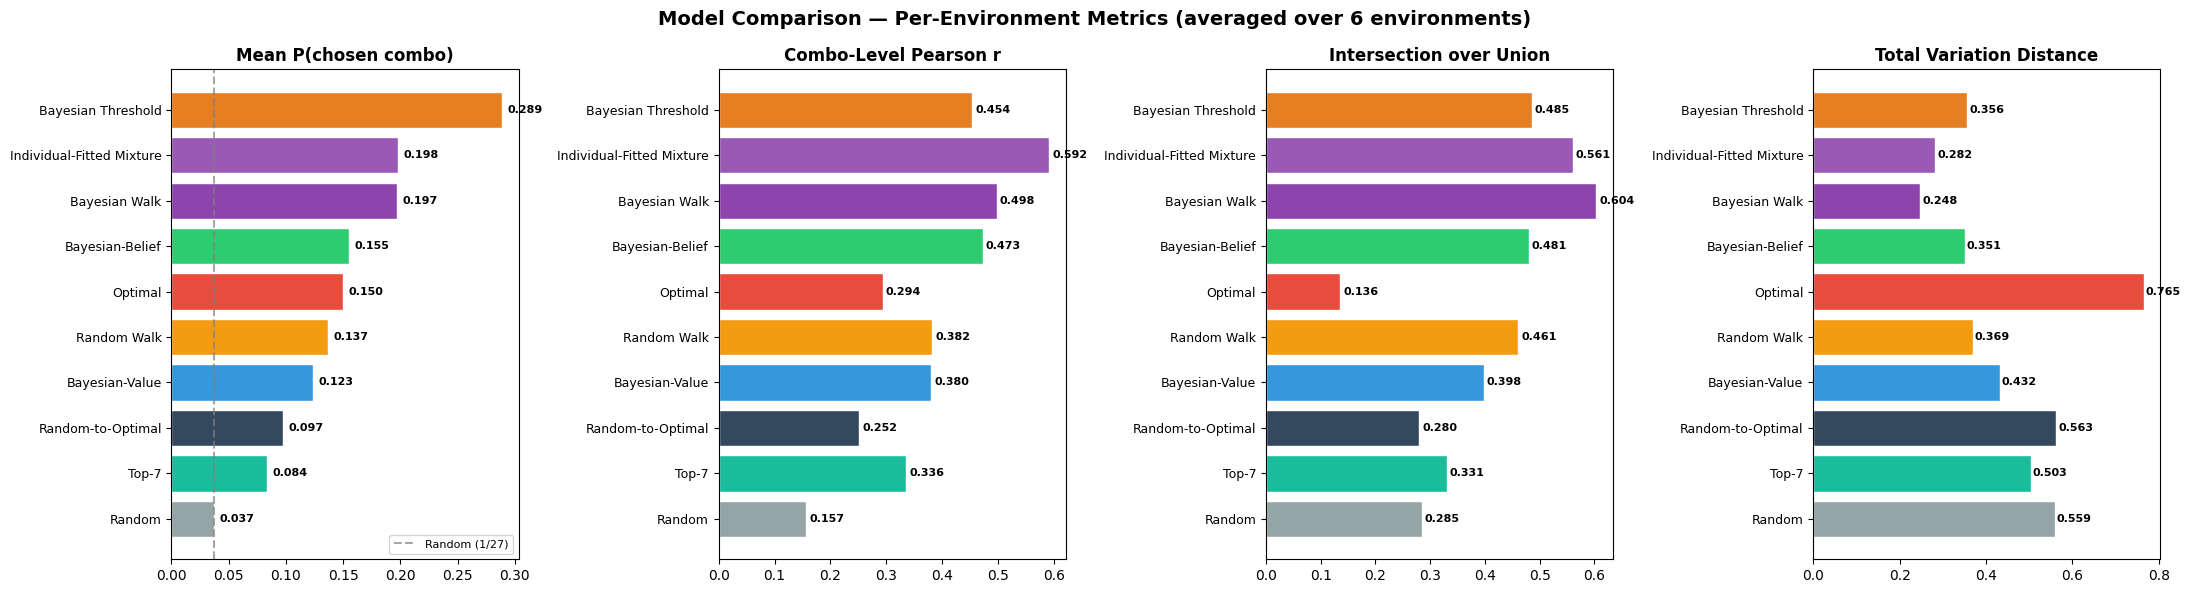

In [6]:

# ========== VISUALIZATION: Summary bar chart ==========
SAVE_DIR = Path('/Users/jolow/coding/bayesian-role-specialization/analysis/experiments/2026-03-30-additional-metrics')

MODEL_COLORS = {
    'Individual-Fitted Mixture': '#9b59b6',
    'Bayesian Walk': '#8e44ad', 'Bayesian Threshold': '#e67e22',
    'Bayesian-Value': '#3498db', 'Bayesian-Belief': '#2ecc71',
    'Random Walk': '#f39c12', 'Optimal': '#e74c3c',
    'Top-7': '#1abc9c', 'Random-to-Optimal': '#34495e', 'Random': '#95a5a6',
}

ordered = metrics_df.index.tolist()
colors = [MODEL_COLORS.get(m, '#95a5a6') for m in ordered]

fig, axes = plt.subplots(1, 4, figsize=(22, 6))

for ax, (col, title, fmt) in zip(axes, [
    ('Mean P(chosen)', 'Mean P(chosen combo)', '{:.3f}'),
    ('combo_r', 'Combo-Level Pearson r', '{:.3f}'),
    ('IoU', 'Intersection over Union', '{:.3f}'),
    ('TVD', 'Total Variation Distance', '{:.3f}'),
]):
    vals = [metrics_df.loc[m, col] for m in ordered]
    ax.barh(range(len(ordered)), vals, color=colors, edgecolor='white')
    ax.set_yticks(range(len(ordered)))
    ax.set_yticklabels(ordered, fontsize=9)
    ax.set_title(title, fontweight='bold')
    ax.invert_yaxis()
    for i, (m, v) in enumerate(zip(ordered, vals)):
        if not np.isnan(v):
            ax.text(max(v, 0) + 0.005, i, fmt.format(v), va='center', fontsize=8, fontweight='bold')
    if col == 'Mean P(chosen)':
        ax.axvline(1/27, color='gray', linestyle='--', alpha=0.7, label='Random (1/27)')
        ax.legend(fontsize=8)

plt.suptitle('Model Comparison — Per-Environment Metrics (averaged over 6 environments)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(SAVE_DIR / 'additional_metrics.png', dpi=150, bbox_inches='tight')
plt.show()


## Scatter Plots: Model Predicted Probability vs Observed Frequency

Each datapoint is one (canonical combo, stage, environment) tuple — the same data that combo_r correlates over. 

- **x-axis**: model's average predicted probability for that combo at that stage
- **y-axis**: empirical frequency of that combo at that stage (across all human teams in that environment)

Most points cluster at (0, 0) — combos that were never observed and rarely predicted. The interesting signal is in the upper-right: does the model assign high probability to combos that humans actually play?

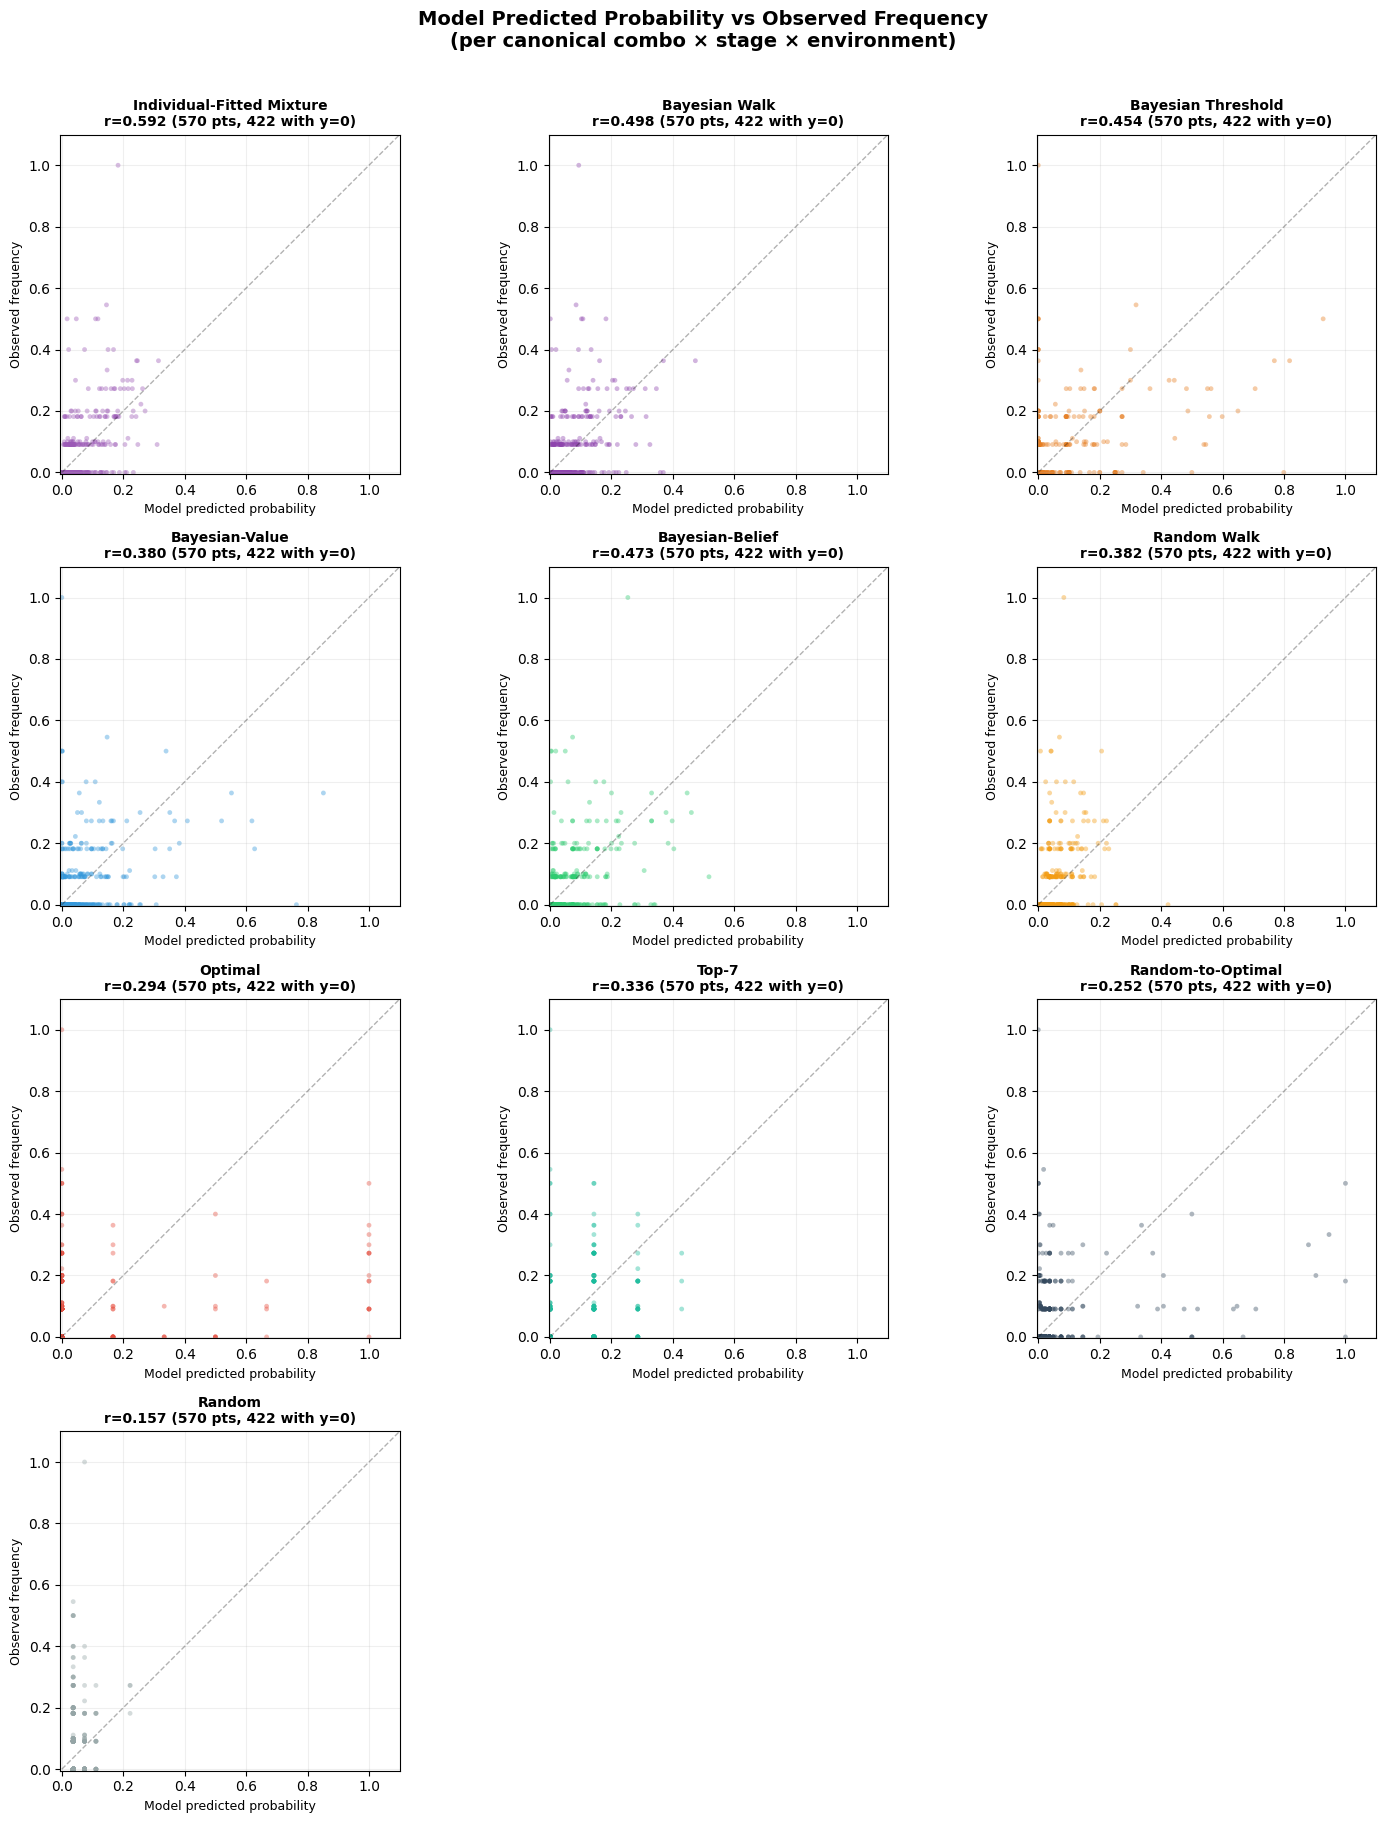

In [12]:

# ========== SCATTER PLOTS: model predicted prob vs observed frequency ==========
# Each datapoint = (canonical combo, stage, environment)
# x = model's average predicted probability for that combo at that stage
# y = empirical frequency of that combo at that stage (across all teams in that env)
# This matches exactly what compute_pearson correlates.

from scipy.stats import pearsonr as _pearsonr

model_names_plot = ['Individual-Fitted Mixture', 'Bayesian Walk', 'Bayesian Threshold', 'Bayesian-Value',
                    'Bayesian-Belief', 'Random Walk', 'Optimal', 'Top-7', 'Random-to-Optimal', 'Random']

ncols = 3
nrows = 4
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 18))

for idx, name in enumerate(model_names_plot):
    ax = axes[idx // ncols][idx % ncols]
    
    # Get the per-(combo, stage, env) data from run_predictions
    all_results = run_predictions(team_records, MODELS[name])
    
    model_probs = []  # x-axis: model predicted probability
    human_freqs = []  # y-axis: observed empirical frequency
    
    for env_id, data in all_results.items():
        for s in range(data['max_stages']):
            predicted = data['stage_predicted'].get(s)
            human_counts = data['stage_human'].get(s, {})
            n = data['stage_counts'].get(s, 0)
            if predicted is None or n == 0:
                continue
            for cc in data['canonical_combos']:
                model_probs.append(predicted.get(cc, 0.0))
                human_freqs.append(human_counts.get(cc, 0) / n)
    
    model_probs = np.array(model_probs)
    human_freqs = np.array(human_freqs)
    
    # Compute r for display (should match compute_pearson)
    if np.std(model_probs) > 1e-10 and np.std(human_freqs) > 1e-10:
        r, _ = _pearsonr(model_probs, human_freqs)
    else:
        r = float('nan')
    
    ax.scatter(model_probs, human_freqs, c=MODEL_COLORS.get(name, '#95a5a6'), 
              s=12, alpha=0.4, edgecolors='none')
    
    max_val = max(model_probs.max(), human_freqs.max()) * 1.1
    ax.plot([0, max_val], [0, max_val], 'k--', alpha=0.3, linewidth=1)
    
    ax.set_xlabel('Model predicted probability', fontsize=9)
    ax.set_ylabel('Observed frequency', fontsize=9)
    n_pts = len(model_probs)
    n_zero = (human_freqs == 0).sum()
    ax.set_title(f'{name}\nr={r:.3f} ({n_pts} pts, {n_zero} with y=0)', 
                fontsize=10, fontweight='bold')
    ax.set_xlim(-0.005, max_val)
    ax.set_ylim(-0.005, max_val)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.2)

for idx in range(len(model_names_plot), nrows * ncols):
    axes[idx // ncols][idx % ncols].set_visible(False)

plt.suptitle('Model Predicted Probability vs Observed Frequency\n(per canonical combo × stage × environment)', 
            fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(SAVE_DIR / 'scatter_pred_vs_obs.png', dpi=150, bbox_inches='tight')
plt.show()


## Key Observations

- **Mean P(chosen)**: Bayesian Threshold leads (28.9%), followed by Individual-Fitted Mixture (19.8%) and Bayesian Walk (19.7%). Random baseline is 3.7% (1/27).
- **TVD**: Bayesian Walk has the lowest TVD (0.248), with Individual-Fitted Mixture second (0.282). Optimal is worst (0.765).
- **IoU**: Bayesian Walk leads (0.604), Individual-Fitted Mixture second (0.561).
- **combo_r**: Now matches the summary notebook exactly. Individual-Fitted Mixture leads (0.592), followed by Bayesian Walk (0.498).
- **Individual-Fitted Mixture** is consistently top-2 across all metrics — best on combo_r, strong on P(chosen)/TVD/IoU.
- **Metric disagreements**: Bayesian Threshold has the highest P(chosen) but low combo_r (0.454) — it concentrates probability sharply, great when right but poor distributional fit overall.

In [8]:

print("MODELS:", len(MODELS) if 'MODELS' in dir() else 'missing')
print("team_records:", len(team_records) if 'team_records' in dir() else 'missing')


MODELS: 10
team_records: 66


In [9]:

def compute_new_metrics(stage_preds_with_env):
    by_env = defaultdict(list)
    for pred_dist, human_combo, env_id in stage_preds_with_env:
        by_env[env_id].append((pred_dist, human_combo))

    env_metrics = []
    combo_to_idx = {c: i for i, c in enumerate(ALL_ROLE_COMBOS)}
    for env_id in env_ids:
        preds = by_env[env_id]
        n = len(preds)
        if n == 0: continue
        choice_probs = [pd.get(hc, 0.0) for pd, hc in preds]
        pred_accum = np.zeros(27)
        obs_counts = np.zeros(27)
        for pd_dict, hc in preds:
            for c in ALL_ROLE_COMBOS:
                pred_accum[combo_to_idx[c]] += pd_dict.get(c, 0.0)
            obs_counts[combo_to_idx[hc]] += 1
        pred_dist = pred_accum / n
        obs_dist = obs_counts / n
        tvd = 0.5 * np.sum(np.abs(pred_dist - obs_dist))
        min_sum = np.sum(np.minimum(pred_dist, obs_dist))
        max_sum = np.sum(np.maximum(pred_dist, obs_dist))
        iou = min_sum / max_sum if max_sum > 0 else 0.0
        env_metrics.append({'mean_choice_prob': np.mean(choice_probs), 'tvd': tvd, 'iou': iou})

    avg = {k: np.mean([em[k] for em in env_metrics]) for k in ['mean_choice_prob', 'tvd', 'iou']}
    
    # Global pred/obs for scatter plots
    n_total = len(stage_preds_with_env)
    global_pred = np.zeros(27)
    global_obs = np.zeros(27)
    for pd_dict, hc, _ in stage_preds_with_env:
        for c in ALL_ROLE_COMBOS:
            global_pred[combo_to_idx[c]] += pd_dict.get(c, 0.0)
        global_obs[combo_to_idx[hc]] += 1
    avg['pred_dist'] = global_pred / n_total
    avg['obs_dist'] = global_obs / n_total
    return avg

# combo_r from shared evaluation, new metrics computed separately
results = {}
for name, fn in MODELS.items():
    shared_results = run_predictions(team_records, fn)
    shared_corrs = compute_pearson(shared_results)
    shared_metrics = extract_metrics(shared_corrs)
    
    new_m = compute_new_metrics(model_env_preds[name])
    new_m['combo_r'] = shared_metrics['combo_r']
    results[name] = new_m

rows = []
for name in MODELS:
    m = results[name]
    rows.append({
        'Model': name,
        'Mean P(chosen)': m['mean_choice_prob'],
        'TVD': m['tvd'],
        'IoU': m['iou'],
        'combo_r': m['combo_r'],
    })

metrics_df = pd.DataFrame(rows).set_index('Model')
metrics_df = metrics_df.sort_values('Mean P(chosen)', ascending=False)

print('='*80)
print('MODEL METRICS — combo_r from shared evaluation (canonical combos, per-stage)')
print('='*80)
print(metrics_df.to_string(float_format='{:.4f}'.format))
print(f'\nRandom baseline P(chosen) = 1/27 = {1/27:.4f}')


MODEL METRICS — combo_r from shared evaluation (canonical combos, per-stage)
                           Mean P(chosen)    TVD    IoU  combo_r
Model                                                           
Bayesian Threshold                 0.2888 0.3559 0.4854   0.4538
Individual-Fitted Mixture          0.1977 0.2820 0.5612   0.5916
Bayesian Walk                      0.1967 0.2483 0.6039   0.4984
Bayesian-Belief                    0.1553 0.3508 0.4811   0.4732
Optimal                            0.1499 0.7651 0.1359   0.2944
Random Walk                        0.1365 0.3694 0.4612   0.3825
Bayesian-Value                     0.1234 0.4317 0.3976   0.3804
Random-to-Optimal                  0.0971 0.5630 0.2803   0.2518
Top-7                              0.0835 0.5034 0.3309   0.3361
Random                             0.0370 0.5588 0.2846   0.1567

Random baseline P(chosen) = 1/27 = 0.0370


In [10]:

# Look at what run_predictions + compute_pearson actually correlate
# For one model, inspect the structure
test_results = run_predictions(team_records, MODELS['Bayesian Walk'])

# Check structure
env_id = list(test_results.keys())[0]
data = test_results[env_id]
print(f"env_id: {env_id}")
print(f"n_teams: {data['n_teams']}")
print(f"max_stages: {data['max_stages']}")
print(f"canonical_combos: {data['canonical_combos']}")
print(f"stage_counts: {data['stage_counts']}")

# What compute_pearson iterates over:
# For each stage s, for each canonical combo cc:
#   combo_m.append(predicted[cc])   <- model avg prob for this combo at this stage
#   combo_h.append(human_count[cc] / n)  <- observed freq for this combo at this stage
# So each datapoint is (combo, stage) within an env

n_points = 0
for s in range(data['max_stages']):
    predicted = data['stage_predicted'].get(s)
    human_counts = data['stage_human'].get(s, {})
    n = data['stage_counts'].get(s, 0)
    if predicted is None or n == 0: continue
    n_points += len(data['canonical_combos'])
    print(f"\n  Stage {s}: {n} teams")
    print(f"    predicted (top 3): {sorted(predicted.items(), key=lambda x:-x[1])[:3]}")
    print(f"    observed  (top 3): {sorted(human_counts.items(), key=lambda x:-x[1])[:3]}")

print(f"\nTotal datapoints for this env: {n_points}")


env_id: 411_222_222_FMM
n_teams: 11
max_stages: 4
canonical_combos: ['FFF', 'FFT', 'FFM', 'FTT', 'FMT', 'FMM', 'TFF', 'TFT', 'TFM', 'TTT', 'TMT', 'TMM', 'MFF', 'MFT', 'MFM', 'MTT', 'MMT', 'MMM']
stage_counts: {0: 11, 1: 11, 2: 10, 3: 1}

  Stage 0: 11 teams
    predicted (top 3): [('FFM', 0.14741519410087112), ('FMT', 0.12681628730162084), ('FFT', 0.12493794949330055)]
    observed  (top 3): [('FMT', 3), ('FTT', 2), ('FFT', 2)]

  Stage 1: 11 teams
    predicted (top 3): [('FMT', 0.24808180884217218), ('FFT', 0.1361748771001393), ('FTT', 0.10275214918690927)]
    observed  (top 3): [('FMM', 6), ('MMM', 2), ('MMT', 1)]

  Stage 2: 10 teams
    predicted (top 3): [('FMM', 0.24528950330776716), ('MMM', 0.13207576657028688), ('FFM', 0.09247322895081947)]
    observed  (top 3): [('FFM', 4), ('FMM', 2), ('FFT', 1)]

  Stage 3: 1 teams
    predicted (top 3): [('MFM', 0.36862617970991485), ('TFM', 0.09895049324961704), ('FFM', 0.09894988059860971)]
    observed  (top 3): [('MFT', 1)]

Total da